In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, classification_report,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('AAPL.csv')
print(df.shape)
df.head()

(890, 9)


,Open,High,Low,Close,Adj Close,Volume,SMA_50,SMA_200,Daily_Return
0,118.720001,121.199997,118.150002,120.709999,118.099770,112559200,116.922999,88.593500,-0.003961
1,121.279999,121.550003,118.809998,119.019997,116.446327,115393800,117.025349,88.813162,-0.014001
2,119.959999,120.419998,115.660004,115.980003,113.472046,120639300,117.122699,89.021275,-0.025542
3,116.199997,118.980003,115.629997,117.510002,114.968956,124423700,117.218349,89.234075,0.013192
4,116.669998,118.709999,116.449997,116.870003,114.342804,89946000,117.368250,89.445437,-0.005446


In [ ]:

d = df.copy()


for lag in [1, 2, 3, 5, 10]:
    d[f'Close_lag{lag}']        = d['Close'].shift(lag)
    d[f'Volume_lag{lag}']       = d['Volume'].shift(lag)
    d[f'Daily_Return_lag{lag}'] = d['Daily_Return'].shift(lag)


for win in [5, 10, 20]:
    d[f'Return_roll_mean_{win}'] = d['Daily_Return'].shift(1).rolling(win).mean()
    d[f'Return_roll_std_{win}']  = d['Daily_Return'].shift(1).rolling(win).std()
    d[f'Close_roll_mean_{win}']  = d['Close'].shift(1).rolling(win).mean()


d['HL_ratio']    = d['High'] / d['Low']
d['OC_ratio']    = d['Open'] / d['Close']
d['Price_SMA50'] = d['Close'] / d['SMA_50']
d['Price_SMA200']= d['Close'] / d['SMA_200']


d['Target_direction'] = (d['Daily_Return'].shift(-1) > 0).astype(int)  
d['Target_close']     = d['Close'].shift(-1)                             

d.dropna(inplace=True)
print(f"Final dataset: {d.shape}")
d.head(3)

Final dataset: (869, 39)


,Open,High,Low,Close,Adj Close,Volume,SMA_50,SMA_200,Daily_Return,Close_lag1,...,Close_roll_mean_10,Return_roll_mean_20,Return_roll_std_20,Close_roll_mean_20,HL_ratio,OC_ratio,Price_SMA50,Price_SMA200,Target_direction,Target_close
20,119.620003,120.529999,118.570000,119.209999,116.833427,103162300,115.1202,92.342937,-0.002343,119.489998,...,114.784,-0.000391,0.025683,115.5785,1.016530,1.003439,1.035526,1.290949,1,119.260002
21,119.440002,119.669998,117.870003,119.260002,116.882439,81581900,115.0878,92.552350,0.000419,119.209999,...,115.173,-0.000310,0.025673,115.5035,1.015271,1.001509,1.036252,1.288568,1,120.300003
22,118.919998,120.989998,118.150002,120.300003,117.901703,91183000,115.0746,92.768025,0.008720,119.260002,...,116.213,0.000411,0.025470,115.5155,1.024037,0.988529,1.045409,1.296783,0,119.389999


In [ ]:

FEATURE_COLS = [c for c in d.columns if c not in
                ('Target_direction', 'Target_close')]

X = d[FEATURE_COLS].values
y_cls = d['Target_direction'].values
y_reg = d['Target_close'].values

split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_cls_train, y_cls_test = y_cls[:split], y_cls[split:]
y_reg_train, y_reg_test = y_reg[:split], y_reg[split:]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class balance (train): {y_cls_train.mean():.2%} up-days")

Train: (695, 37)  |  Test: (174, 37)
Class balance (train): 51.22% up-days


In [ ]:

tscv = TimeSeriesSplit(n_splits=5)

clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)


cv_scores = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    clf.fit(X_train[tr_idx], y_cls_train[tr_idx],
            eval_set=[(X_train[val_idx], y_cls_train[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(-1)])
    preds = clf.predict(X_train[val_idx])
    acc = accuracy_score(y_cls_train[val_idx], preds)
    cv_scores.append(acc)
    print(f"  Fold {fold+1}: accuracy = {acc:.4f}")

print(f"\nCV mean accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

#  evaluate on test
clf.fit(X_train, y_cls_train, eval_set=[(X_test, y_cls_test)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
y_pred_cls = clf.predict(X_test)
print(f"\nTest accuracy: {accuracy_score(y_cls_test, y_pred_cls):.4f}")
print(classification_report(y_cls_test, y_pred_cls, target_names=['Down','Up']))

  Fold 1: accuracy = 0.5391
  Fold 2: accuracy = 0.5652
  Fold 3: accuracy = 0.5478
  Fold 4: accuracy = 0.4957
  Fold 5: accuracy = 0.5130

CV mean accuracy: 0.5322 ± 0.0248

Test accuracy: 0.5230
              precision    recall  f1-score   support

        Down       0.53      0.40      0.46        87
          Up       0.52      0.64      0.57        87

    accuracy                           0.52       174
   macro avg       0.52      0.52      0.52       174
weighted avg       0.52      0.52      0.52       174



In [ ]:
# – Regression (next-day close price)
reg = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

reg.fit(X_train, y_reg_train,
        eval_set=[(X_test, y_reg_test)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

y_pred_reg = reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
mae  = mean_absolute_error(y_reg_test, y_pred_reg)
r2   = r2_score(y_reg_test, y_pred_reg)

print(f"Regression – Next-day Close price")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")

Regression – Next-day Close price
  RMSE : 3.3114
  MAE  : 2.5980
  R²   : 0.8561


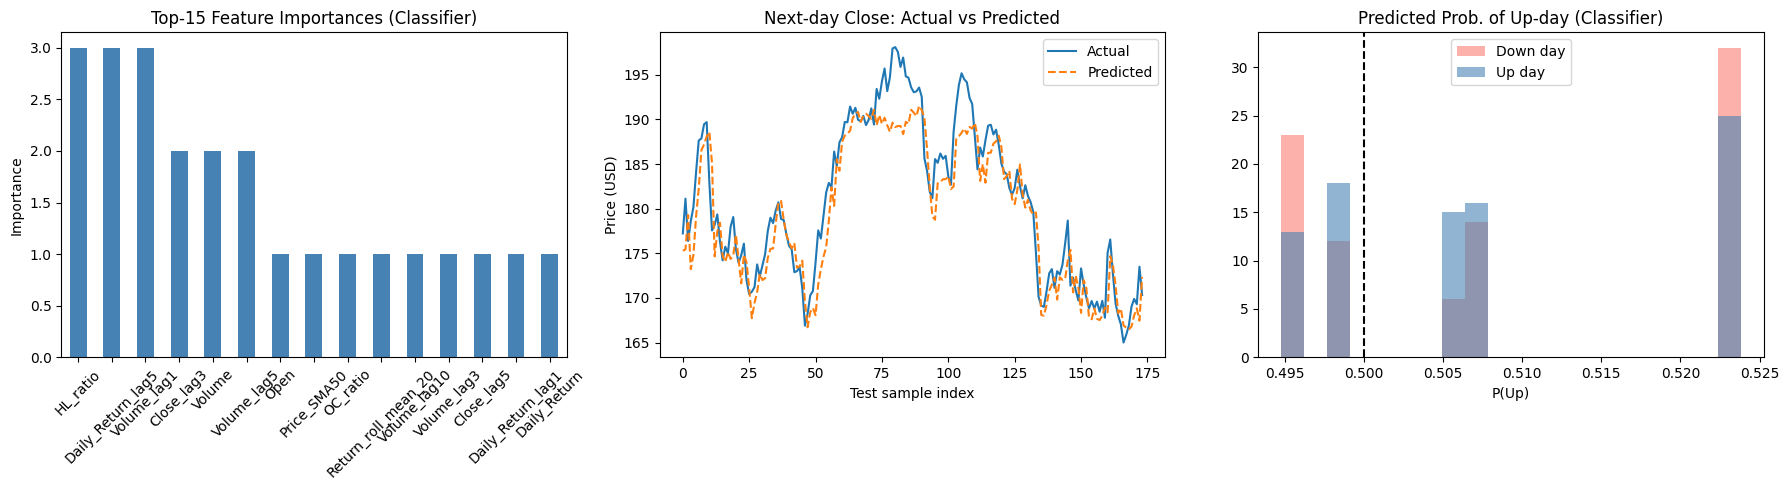

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#(classifier)
fi = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fi.head(15).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top-15 Feature Importances (Classifier)')
axes[0].set_ylabel('Importance')
axes[0].tick_params(axis='x', rotation=45)

# (regression)
axes[1].plot(y_reg_test, label='Actual', linewidth=1.5)
axes[1].plot(y_pred_reg, label='Predicted', linewidth=1.5, linestyle='--')
axes[1].set_title('Next-day Close: Actual vs Predicted')
axes[1].set_xlabel('Test sample index')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

# distribution
proba = clf.predict_proba(X_test)[:, 1]
axes[2].hist(proba[y_cls_test == 0], bins=20, alpha=0.6, label='Down day', color='salmon')
axes[2].hist(proba[y_cls_test == 1], bins=20, alpha=0.6, label='Up day',   color='steelblue')
axes[2].axvline(0.5, color='black', linestyle='--')
axes[2].set_title('Predicted Prob. of Up-day (Classifier)')
axes[2].set_xlabel('P(Up)')
axes[2].legend()

plt.tight_layout()
plt.show()